In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import re

In [ ]:
engine = create_engine(
    "...."
)

query = query = """
                SELECT 
                    dt,
                    ad_account_name,
                    objective,
                    SUM(spend) AS spend,
                    SUM(impressions) AS impressions

                FROM intern_fact_meta_insights_daily

                WHERE ad_account_id IN (
                    SELECT ad_account_id
                    FROM intern_fact_meta_insights_daily
                    WHERE dt BETWEEN '2025-12-31' AND '2026-05-30'
                    GROUP BY ad_account_id
                    HAVING SUM(spend) > 0
                )

                GROUP BY 
                    dt,
                    ad_account_name,
                    objective

                ORDER BY dt
                """
df = pd.read_sql(query, engine)

print(df.head(10))


           dt            ad_account_name      objective     spend  impressions
0  2025-01-01  014 Eta - LP Form Adhimas    LINK_CLICKS   16230.0       3881.0
1  2025-01-01  014 Eta - LP Form Adhimas  OUTCOME_LEADS  669023.0     151199.0
2  2025-01-01  014 Eta - LP Form Adhimas  OUTCOME_SALES  541714.0     114032.0
3  2025-01-01     047 Eta - LP Form Ifan  OUTCOME_LEADS   97347.0      10295.0
4  2025-01-01     047 Eta - LP Form Ifan  OUTCOME_SALES   60790.0       5061.0
5  2025-01-02  014 Eta - LP Form Adhimas    LINK_CLICKS   16630.0       3963.0
6  2025-01-02  014 Eta - LP Form Adhimas  OUTCOME_LEADS  649224.0      95645.0
7  2025-01-02  014 Eta - LP Form Adhimas  OUTCOME_SALES  500089.0      67845.0
8  2025-01-02     047 Eta - LP Form Ifan  OUTCOME_LEADS  109041.0       7105.0
9  2025-01-02     047 Eta - LP Form Ifan  OUTCOME_SALES   11500.0        920.0


In [114]:
# # ==============================
# # BRAND SELECTION
# # ==============================
BRAND = "egn"


In [115]:
from preprocessing import preprocess_data
ts= preprocess_data(df, BRAND)


FINAL DATA COLUMNS
['spend_egn_awareness', 'spend_egn_conversion', 'spend_egn_click', 'impr_egn', 'total_spend', 'is_outlier', 'outlier_type']

TOTAL DATA : 137


In [116]:
# X = ts.drop(columns=[f"impr_{BRAND}"]).values 
X = ts.drop(columns=[
    f"impr_{BRAND}",
    "outlier_type",
    "is_outlier"
]).copy()

y = ts[f"impr_{BRAND}"].values

train_ratio = 0.85
cut_train = int(len(X) * train_ratio)

X_train, X_test = X[:cut_train], X[cut_train:]
y_train, y_test = y[:cut_train], y[cut_train:]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (104, 34)
Test : (19, 34)


In [117]:
ts.head(10)

,spend_egn_awareness,spend_egn_conversion,spend_egn_click,impr_egn,total_spend,is_outlier,outlier_type,lag_impr_1,lag_spend_awareness_1,lag_spend_conversion_1,...,impr_roll7,spend_awareness_roll7,spend_conversion_roll7,spend_click_roll7,impr_diff,spend_awareness_diff,spend_conversion_diff,spend_click_diff,day_of_week,is_weekend
dt,,,,,,,,,,,,,,,,,,,,,
2026-01-15,166198.0,4147339.0,149112.0,296379.0,4462649.0,False,normal,169694.0,105392.0,1950477.0,...,324236.142857,177253.714286,4.050024e+06,153893.428571,-220764.0,-121556.0,-3325017.0,-99975.0,3,0
2026-01-16,172826.0,3829884.0,124090.0,309722.0,4126800.0,False,normal,296379.0,166198.0,4147339.0,...,317052.571429,173131.285714,4.029478e+06,153688.285714,126685.0,60806.0,2196862.0,76566.0,4,0
2026-01-17,147575.0,3071768.0,140227.0,293696.0,3359570.0,False,normal,309722.0,172826.0,3829884.0,...,314586.000000,173592.000000,3.972824e+06,149652.142857,13343.0,6628.0,-317455.0,-25022.0,5,1
2026-01-18,243076.0,3756001.0,188492.0,356159.0,4187569.0,False,normal,293696.0,147575.0,3071768.0,...,316029.714286,173260.000000,3.903646e+06,149152.571429,-16026.0,-25251.0,-758116.0,16137.0,6,1
2026-01-19,241885.0,3978637.0,188764.0,456930.0,4409286.0,False,normal,356159.0,243076.0,3756001.0,...,314617.714286,179917.142857,3.873020e+06,145799.571429,62463.0,95501.0,684233.0,48265.0,0,0
2026-01-20,227771.0,5818474.0,195707.0,453166.0,6241952.0,False,normal,456930.0,241885.0,3978637.0,...,324719.714286,186271.428571,3.715657e+06,147964.571429,100771.0,-1191.0,222636.0,272.0,1,0
2026-01-21,279050.0,6648571.0,220937.0,569483.0,7148558.0,False,normal,453166.0,227771.0,5818474.0,...,333678.000000,186389.000000,3.793226e+06,151276.857143,-3764.0,-14114.0,1839837.0,6943.0,2,0
2026-01-22,267927.0,6798523.0,198368.0,586501.0,7264818.0,False,normal,569483.0,279050.0,6648571.0,...,390790.714286,211197.285714,4.464382e+06,172475.571429,116317.0,51279.0,830097.0,25230.0,3,0
2026-01-23,271502.0,7252679.0,258950.0,582374.0,7783131.0,False,normal,586501.0,267927.0,6798523.0,...,432236.714286,225730.000000,4.843123e+06,179512.142857,17018.0,-11123.0,149952.0,-22569.0,4,0


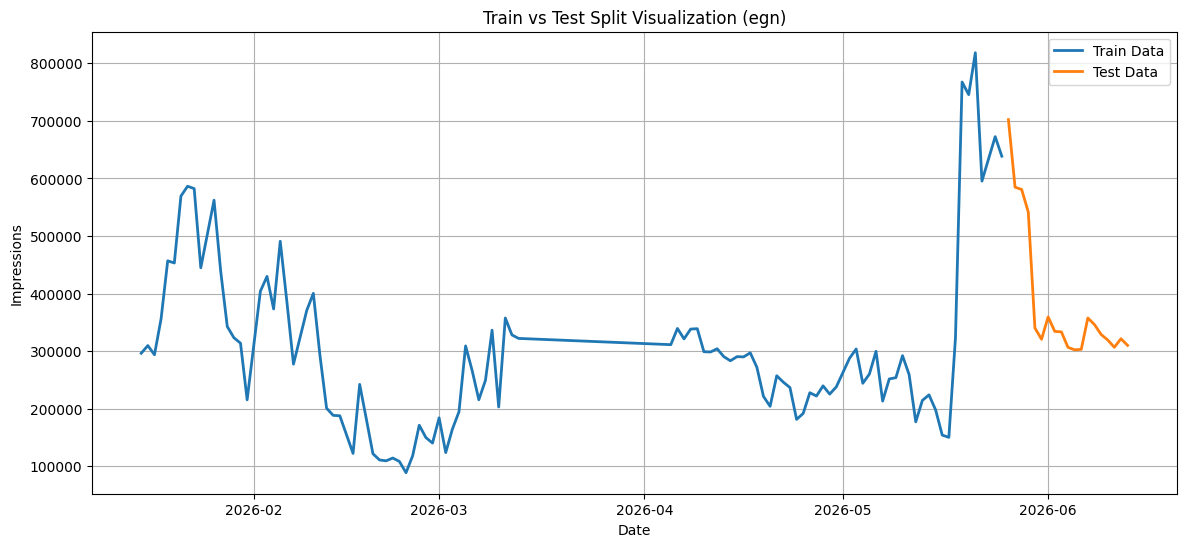

In [118]:
plt.figure(figsize=(14,6))

# =========================
# INDEX
# =========================
train_index = ts.index[:cut_train]
test_index  = ts.index[cut_train:]

# =========================
# PLOT TRAIN
# =========================
plt.plot(train_index, ts.loc[train_index, f"impr_{BRAND}"],
         label="Train Data", linewidth=2)

# =========================
# PLOT TEST
# =========================
plt.plot(test_index, ts.loc[test_index, f"impr_{BRAND}"],
         label="Test Data",linewidth=2)



# =========================
# FINAL
# =========================
plt.title(f"Train vs Test Split Visualization ({BRAND})")
plt.xlabel("Date")
plt.ylabel("Impressions")
plt.legend()
plt.grid(True)

plt.show()

In [119]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    subsample=0.6,
    colsample_bytree=0.6,
    reg_alpha=1.7,
    reg_lambda=1.7,
    random_state=42
)

model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [120]:
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

In [121]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance[
    importance["feature"] != "total_spend"
]

importance = importance[
    ~importance["feature"].str.contains("roll")
]

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance)

                    feature  importance
7         lag_spend_click_1    0.183484
4                lag_impr_1    0.160906
0       spend_egn_awareness    0.122097
5     lag_spend_awareness_1    0.077872
2           spend_egn_click    0.061716
18   lag_spend_conversion_7    0.040003
16               lag_impr_7    0.027955
11        lag_spend_click_2    0.027137
14   lag_spend_conversion_3    0.019693
1      spend_egn_conversion    0.016829
19        lag_spend_click_7    0.016444
15        lag_spend_click_3    0.014033
8                lag_impr_2    0.013203
12               lag_impr_3    0.011931
29     spend_awareness_diff    0.011609
17    lag_spend_awareness_7    0.009692
28                impr_diff    0.006183
21   lag_spend_awareness_14    0.005978
20              lag_impr_14    0.005202
13    lag_spend_awareness_3    0.005022
23       lag_spend_click_14    0.004812
31         spend_click_diff    0.004540
32              day_of_week    0.004453
6    lag_spend_conversion_1    0.004314


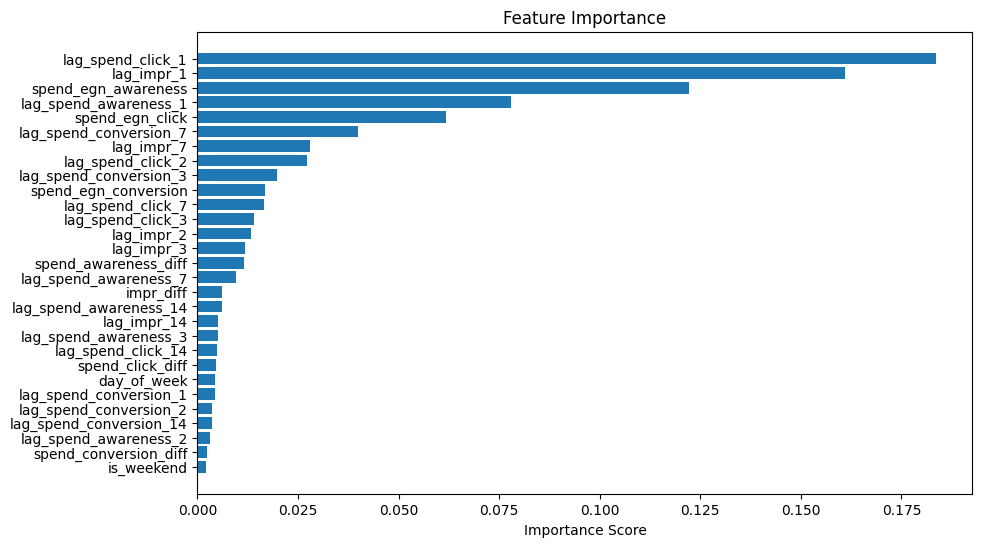

In [122]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.show()

In [123]:
import shap

explainer = shap.Explainer(model)

shap_values = explainer(X_test)

In [124]:
exclude_cols = [
    col for col in X_test.columns
    if col == "total_spend" or "roll" in col
]

keep_cols = [
    col for col in X_test.columns
    if col not in exclude_cols
]


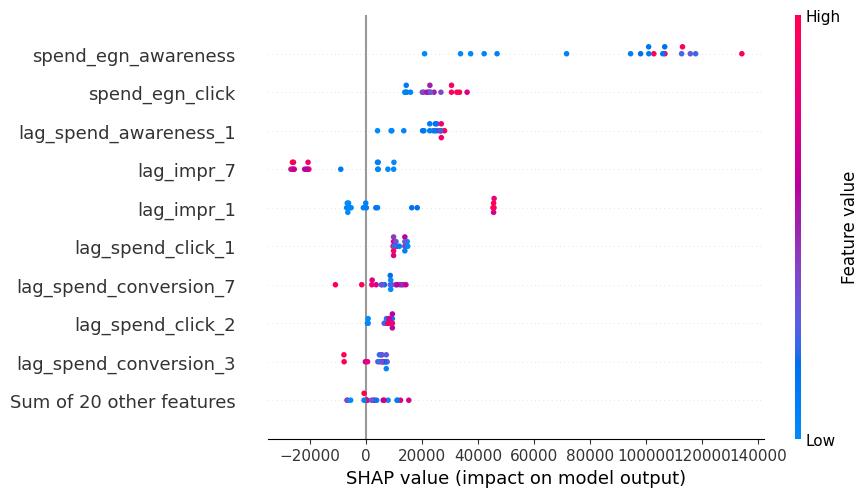

In [125]:
shap.plots.beeswarm(
    shap_values[:, keep_cols]
)

In [126]:
# shap.plots.scatter(
#     shap_values[:, "spend_egn_awareness"]
# )

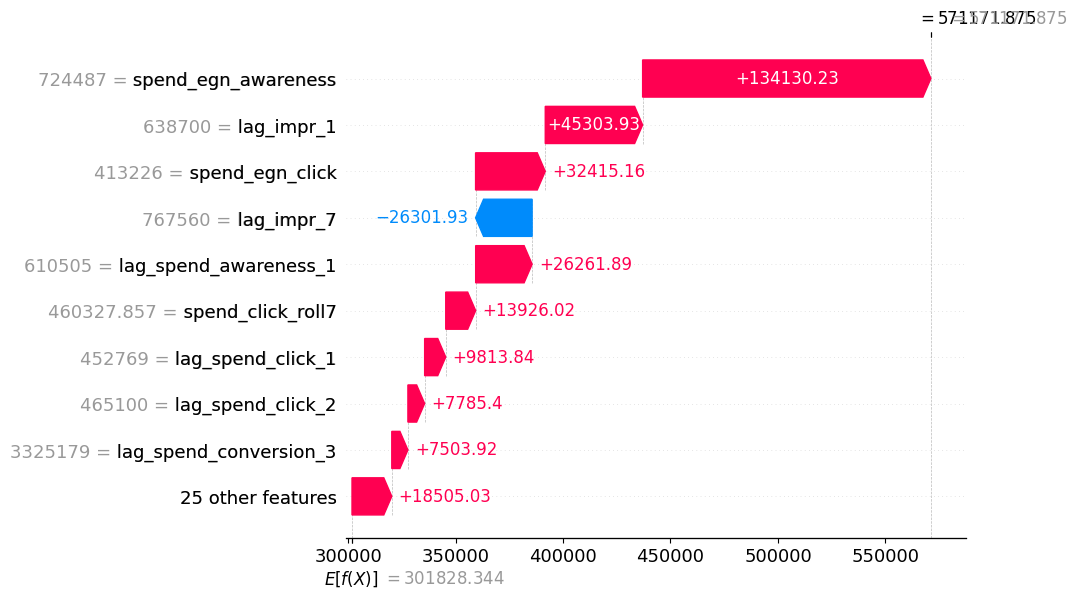

In [127]:
shap.plots.waterfall(
    shap_values[0]
)

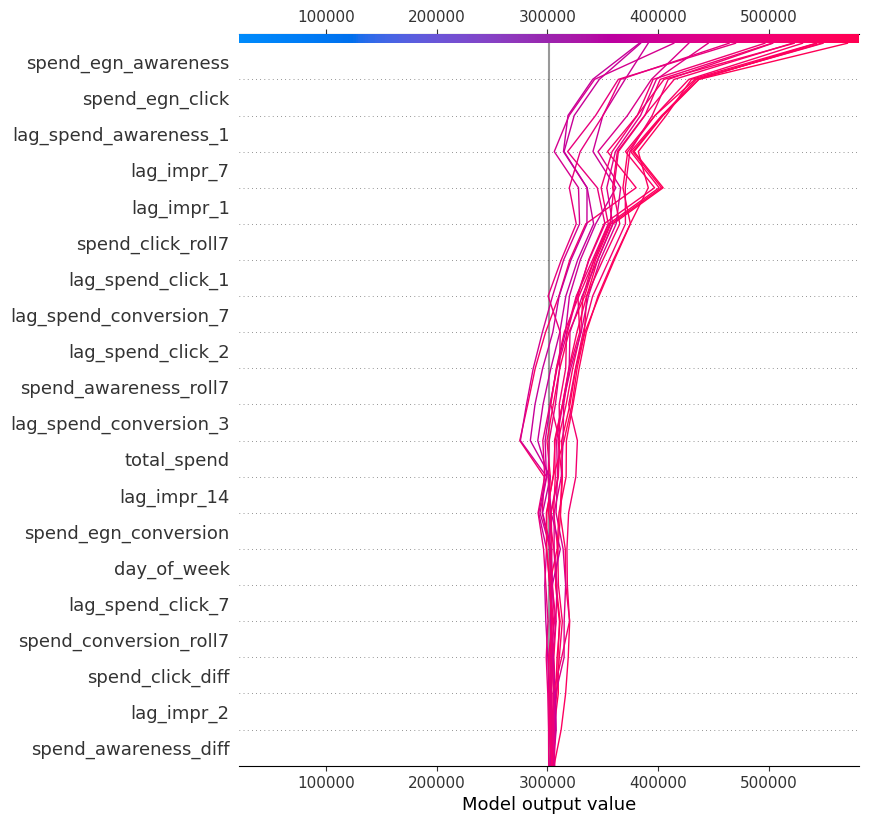

In [128]:
shap.decision_plot(
    explainer.expected_value,
    shap_values.values,
    X
)

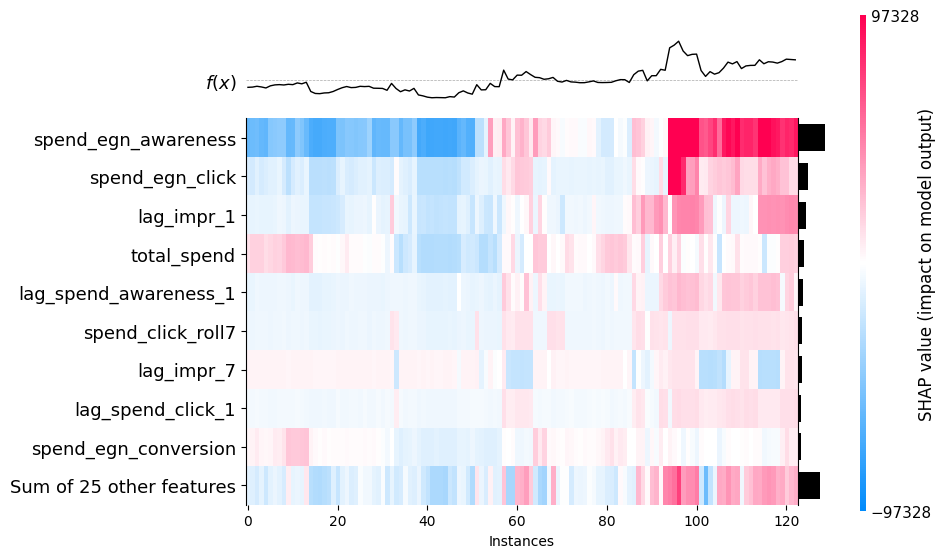

<Axes: xlabel='Instances'>

In [129]:

explainer = shap.Explainer(model, X)

shap_values = explainer(X)

shap.plots.heatmap(shap_values)

In [130]:
def calculate_metrics(y_true, y_pred):
    yt = y_true.flatten()
    yp = y_pred.flatten()

    rmse = np.sqrt(mean_squared_error(yt, yp))

    mask = yt != 0
    mape = np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100

    wape = np.sum(np.abs(yt - yp)) / np.sum(np.abs(yt)) * 100

    return rmse, mape, wape

train_rmse, train_mape, train_wape = calculate_metrics(y_train, y_train_pred)
test_rmse,  test_mape,  test_wape  = calculate_metrics(y_test,  y_test_pred)

def fmt(x):
    return f"{x:.2f}".replace('.', ',')

print("\n===== TRAIN METRICS =====")
print(f"RMSE : {fmt(train_rmse)}")
print(f"MAPE : {fmt(train_mape)}%")
print(f"WAPE : {fmt(train_wape)}%")

print("\n===== TEST METRICS =====")
print(f"RMSE : {fmt(test_rmse)}")
print(f"MAPE : {fmt(test_mape)}%")
print(f"WAPE : {fmt(test_wape)}%")



===== TRAIN METRICS =====
RMSE : 15572,02
MAPE : 4,45%
WAPE : 3,77%

===== TEST METRICS =====
RMSE : 140419,19
MAPE : 36,58%
WAPE : 32,29%


In [131]:
def calculate_total_metrics(
    y_train,
    y_train_pred,
    y_test,
    y_test_pred
):

    all_actual = np.concatenate([
        y_train,
        y_test
    ])

    all_pred = np.concatenate([
        y_train_pred,
        y_test_pred
    ])

    # =========================
    # RMSE
    # =========================
    all_rmse = np.sqrt(
        mean_squared_error(
            all_actual,
            all_pred
        )
    )

    # =========================
    # MAPE
    # =========================
    mask = all_actual != 0

    all_mape = np.mean(
        np.abs(
            (all_actual[mask] - all_pred[mask])
            /
            all_actual[mask]
        )
    ) * 100

    # =========================
    # WAPE
    # =========================
    all_wape = (
        np.sum(np.abs(all_actual - all_pred))
        /
        np.sum(np.abs(all_actual))
    ) * 100

    return all_rmse, all_mape, all_wape

In [132]:
all_rmse, all_mape, all_wape = (
    calculate_total_metrics(
        y_train,
        y_train_pred,
        y_test,
        y_test_pred
    )
)

print(f"ALL_RMSE : {fmt(all_rmse)}")
print(f"ALL_MAPE : {fmt(all_mape)}%")
print(f"ALL_WAPE : {fmt(all_wape)}%")

ALL_RMSE : 57016,06
ALL_MAPE : 9,41%
ALL_WAPE : 9,13%


SAVE MODELS

In [141]:
import os
import joblib
import numpy as np

# =========================
# FOLDER
# =========================
BASE_DIR = "models3"

brand_dir = os.path.join(BASE_DIR, BRAND)

os.makedirs(brand_dir, exist_ok=True)

# =========================
# SAVE MODEL
# =========================
joblib.dump(model,
            os.path.join(brand_dir, "model.pkl"))

joblib.dump(X.columns.tolist(),
            os.path.join(brand_dir, "features.pkl"))

# =========================
# METRICS
# =========================
metrics = {
    "train_rmse": train_rmse,
    "train_mape": train_mape,
    "train_wape": train_wape,
    "test_rmse": test_rmse,
    "test_mape": test_mape,
    "test_wape": test_wape,
    "all_rmse": all_rmse,
    "all_mape": all_mape,
    "all_wape": all_wape
}

joblib.dump(metrics,
            os.path.join(brand_dir, "metrics.pkl"))

# =========================
# RESIDUALS
# =========================
mask = y_train != 0

residuals = ((y_train - y_train_pred) / y_train)[mask]

residuals = residuals[np.isfinite(residuals)]

residuals = np.clip(residuals, -1, 1)

joblib.dump(residuals,
            os.path.join(brand_dir, "residuals.pkl"))

# =========================
# TEST PRED
# =========================
df_test_pred = pd.DataFrame({
    "date": X_test.index,
    "prediction": y_test_pred
}).set_index("date")

joblib.dump(df_test_pred,
            os.path.join(brand_dir, "test_pred.pkl"))

print(f"✅ Saved to {brand_dir}")

✅ Saved to models3\egn


PREDICTION

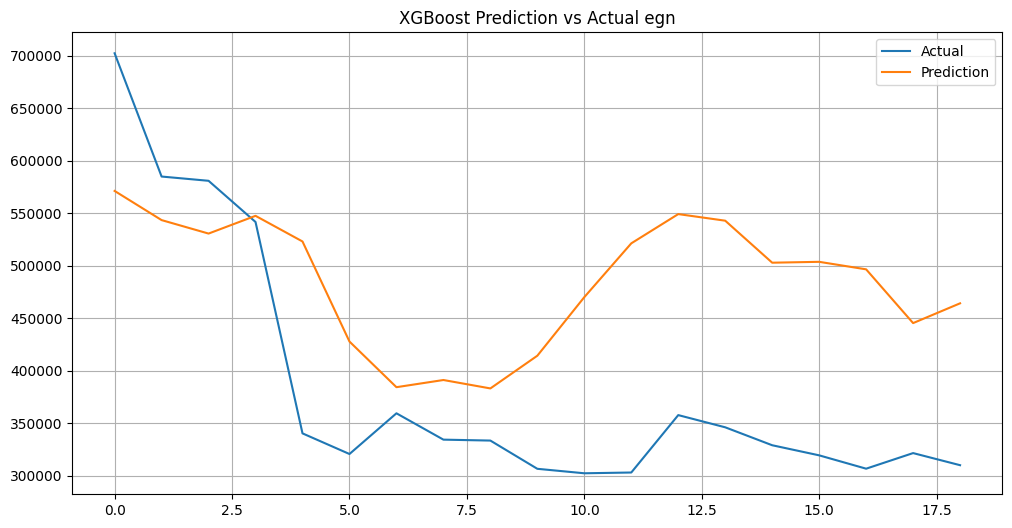

In [134]:
plt.figure(figsize=(12,6))
plt.plot(y_test, label="Actual")
plt.plot(y_test_pred, label="Prediction")
plt.title(f"XGBoost Prediction vs Actual {BRAND}")
plt.legend()
plt.grid()
plt.show()

In [135]:
def forecast_n_step(model, ts, BRAND, steps):

    ts_future = ts.copy()
    predictions = []

    for i in range(steps):

        last_row = ts_future.iloc[-1:].copy()

        # =========================
        # LAG FEATURES
        # =========================
        for lag in [1,2,3,7,14]:

            # impression lag
            last_row[f'lag_impr_{lag}'] = (
                ts_future[f'impr_{BRAND}'].iloc[-lag]
            )

            # awareness lag
            last_row[f'lag_spend_awareness_{lag}'] = (
                ts_future[f"spend_{BRAND}_awareness"]
                .iloc[-lag]
            )

            # conversion lag
            last_row[f'lag_spend_conversion_{lag}'] = (
                ts_future[f"spend_{BRAND}_conversion"]
                .iloc[-lag]
            )

            # click lag
            last_row[f'lag_spend_click_{lag}'] = (
                ts_future[f"spend_{BRAND}_click"]
                .iloc[-lag]
            )

        # =========================
        # DIFF FEATURES
        # =========================
        last_row['impr_diff'] = (
            ts_future[f"impr_{BRAND}"]
            .diff()
            .iloc[-1]
        )

        last_row['spend_awareness_diff'] = (
            ts_future[f"spend_{BRAND}_awareness"]
            .diff()
            .iloc[-1]
        )

        last_row['spend_conversion_diff'] = (
            ts_future[f"spend_{BRAND}_conversion"]
            .diff()
            .iloc[-1]
        )

        last_row['spend_click_diff'] = (
            ts_future[f"spend_{BRAND}_click"]
            .diff()
            .iloc[-1]
        )

        # =========================
        # NEXT DATE
        # =========================
        next_date = ts_future.index[-1] + pd.Timedelta(days=1)

        last_row.index = [next_date]

        # =========================
        # TIME FEATURES
        # =========================
        last_row['day_of_week'] = next_date.dayofweek

        last_row['is_weekend'] = int(
            next_date.dayofweek >= 5
        )

        # =========================
        # PREDICT
        # =========================
        X_pred = last_row.drop(
            columns=[f"impr_{BRAND}"],
            errors='ignore'
        )

        X_pred = X_pred[X.columns].fillna(0)

        y_pred = model.predict(X_pred)[0]

        # =========================
        # APPEND PREDICTION
        # =========================
        last_row[f"impr_{BRAND}"] = y_pred

        predictions.append(
            (next_date, y_pred)
        )

        ts_future = pd.concat([
            ts_future,
            last_row
        ])

    return pd.DataFrame(
        predictions,
        columns=["date", "prediction"]
    )

In [136]:
df_pred_7 = forecast_n_step(model, ts, BRAND, steps=7)

print("\n=== Forecast 7 Hari ===")
print(df_pred_7)



=== Forecast 7 Hari ===
        date    prediction
0 2026-06-14  428122.25000
1 2026-06-15  495176.90625
2 2026-06-16  505960.03125
3 2026-06-17  528105.75000
4 2026-06-18  523505.00000
5 2026-06-19  505233.96875
6 2026-06-20  523735.37500


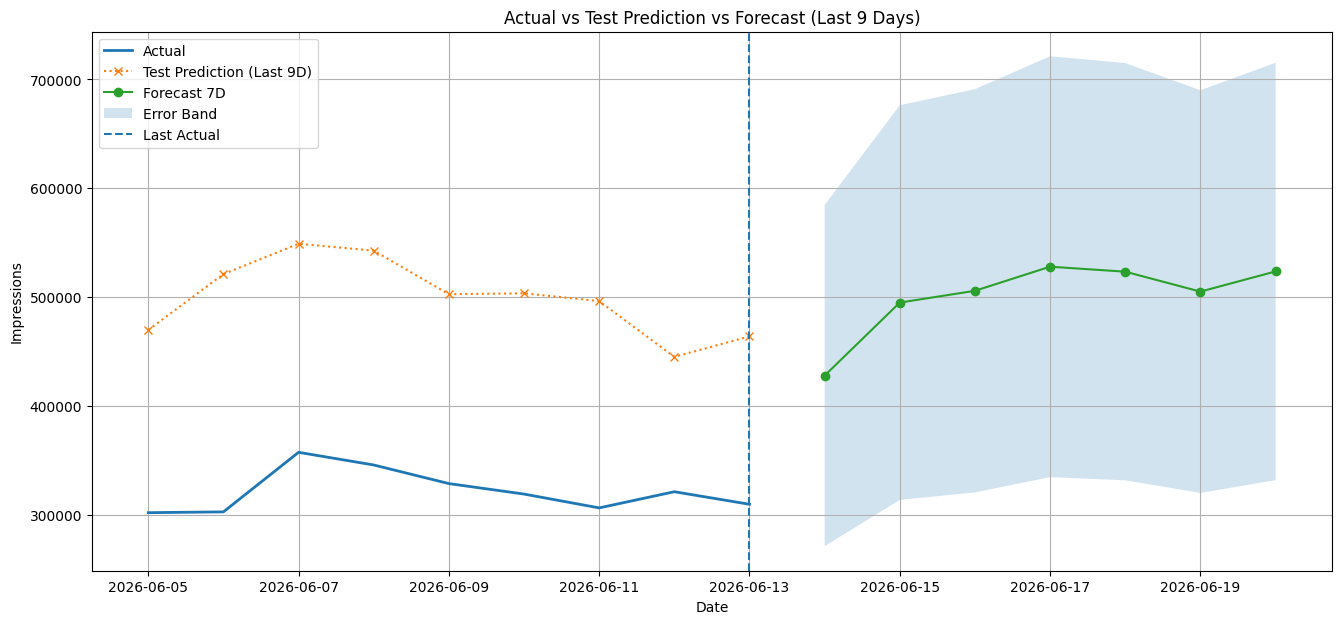

In [137]:
view = 9

# actual last N hari
last_actual = ts.tail(view)

# test prediction FULL
test_pred_series = pd.Series(y_test_pred, index=X_test.index)

# ✅ ambil hanya yang overlap dengan last_actual
test_pred_last = test_pred_series.reindex(last_actual.index)


plt.figure(figsize=(16,7))

# =========================
# ACTUAL (LAST N)
# =========================
plt.plot(last_actual.index, last_actual[f"impr_{BRAND}"], 
         label="Actual", linewidth=2)

# =========================
# TEST PRED (LAST N 🔥)
# =========================
plt.plot(test_pred_last.index, test_pred_last, 
         label=f"Test Prediction (Last {view}D)", 
         linestyle=':', marker='x')

# =========================
# FORECAST
# =========================
plt.plot(df_pred_7["date"], df_pred_7["prediction"], 
         label="Forecast 7D", marker='o')

# =========================
# ERROR BAND
# =========================
error_rate = test_mape / 100

plt.fill_between(df_pred_7["date"], 
                 df_pred_7["prediction"]*(1-error_rate),
                 df_pred_7["prediction"]*(1+error_rate),
                 alpha=0.2, label="Error Band")

# =========================
# LAST ACTUAL LINE
# =========================
plt.axvline(x=last_actual.index[-1], linestyle='--', label="Last Actual")

# =========================
# FINAL
# =========================
plt.title(f"Actual vs Test Prediction vs Forecast (Last {view} Days)")
plt.xlabel("Date")
plt.ylabel("Impressions")
plt.legend()
plt.grid(True)

plt.show()

In [138]:
def autocorr_lag1(y):
    y_t = y[1:]
    y_tm1 = y[:-1]

    return np.corrcoef(y_t, y_tm1)[0, 1]

y_series = ts[f"impr_{BRAND}"].values
rho = autocorr_lag1(y_series)

print("Autocorrelation lag-1:", rho)

Autocorrelation lag-1: 0.8679158265593946


In [139]:
def estimate_theta(y):
    y_t = y[1:]
    y_tm1 = y[:-1]
    theta = np.sum(y_t * y_tm1) / np.sum(y_tm1**2)
    return theta

In [140]:

theta = estimate_theta(y_series)

print("Theta:", theta)



Theta: 0.9763976840622337
